# Nemenyi post-hoc + Critical-Difference (CD) diagrams

**Extends the Friedman omnibus tests (Section 6.4 / Table 6.2).**

Following Demsar (2006): a significant Friedman test is followed by the **Nemenyi**
pairwise post-hoc to identify *which* model pairs differ, shown as a
**critical-difference (CD) diagram**.

Paths are anchored to the **repo root** (detected automatically), so this works
whether you run it from the repo root or from `notebooks/v1.0-trainval/`.

**Order:** run the inspection cell, confirm your column names, set `DEMO=False`,
Run All. The printed Friedman chi-square must match **Table 6.2**.

> **Caveat for the report:** blocks are repeated fold-seed runs, *not* independent
> datasets, so keep framing Nemenyi as **supplementary** evidence.


In [2]:
# !pip install -U scikit-posthocs   # uncomment once; needs >= 0.7 for CD diagram

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare

%matplotlib inline

def _repo_root(start=None):
    '''Walk up from cwd to the repo root: folder with .git, or with both
    notebooks/ and results/ subfolders. Falls back to cwd if not found.'''
    start = Path(start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        if (base / ".git").exists():
            return base
        if (base / "notebooks").is_dir() and (base / "results").is_dir():
            return base
    return start

In [3]:
# ============================ CONFIG ============================
REPO_ROOT = _repo_root()
print("Detected repo root:", REPO_ROOT)
# If the line above is wrong, set it manually, e.g.:
# REPO_ROOT = Path(r"C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml")

RESULTS_CSV = str(REPO_ROOT / "results" / "v1.0-trainval" / "metrics" / "all_metrics.csv")
OUT_DIR     = str(REPO_ROOT / "results" / "v1.0-trainval" / "figures")  # CD diagrams saved here

# >>> The COL_* values below are GUESSES from the report. Run the next cell and
# >>> confirm they match your real headers before setting DEMO=False. <<<
COL_MODEL     = "model"        # LogReg / SVM / RF / XGB / MLP
COL_ATTRIBUTE = "attribute"    # time_of_day / weather / vehicle_density / vru_present
COL_CONFIG    = "version"       # values like "tuned" / "base"
COL_SEED      = "seed"
COL_FOLD      = "fold"
COL_SCORE     = "macro_f1"

TUNED_VALUE   = "tuned"
ALPHA         = 0.05
ATTRIBUTES    = ["time_of_day", "weather", "vehicle_density", "vru_present"]

Q_ALPHA_05 = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728,
              6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164}

# DEMO=True -> synthetic data (every output stamped DEMO; never report it).
# DEMO=False -> loads your real CSV; raises a clear error if it cannot be found.
DEMO = False

Detected repo root: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml


In [4]:
# ---- Inspect YOUR results file, then confirm the COL_* names in CONFIG ----
if os.path.exists(RESULTS_CSV):
    _raw = pd.read_csv(RESULTS_CSV)
    print("Found:", RESULTS_CSV)
    print("Rows:", len(_raw), "| Columns:", list(_raw.columns))
    for col in _raw.columns:
        low = col.lower()
        if any(key in low for key in ["config", "tuned", "seed", "fold", "model", "attr"]):
            vals = _raw[col].unique()
            shown = ", ".join(map(str, vals[:12])) + (" ..." if len(vals) > 12 else "")
            print(f"  {col}: {shown}")
    display(_raw.head())
else:
    print("Not found:", RESULTS_CSV)
    print("Repo root detected as:", REPO_ROOT, "| cwd:", Path.cwd())
    print("If repo root is wrong, set REPO_ROOT manually in CONFIG, then re-run.")

Found: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml\results\v1.0-trainval\metrics\all_metrics.csv
Rows: 600 | Columns: ['accuracy', 'macro_f1', 'weighted_f1', 'macro_precision', 'macro_recall', 'auc', 'attribute', 'model', 'version', 'seed', 'fold', 'best_params']
  attribute: time_of_day, weather, vehicle_density, vru_present
  model: LogisticRegression, SVM_RBF, RandomForest, XGBoost, MLP
  seed: 42, 7, 123
  fold: 0, 1, 2, 3, 4


,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,auc,attribute,model,version,seed,fold,best_params
0,0.99335,0.989491,0.993308,0.995876,0.983402,0.999862,time_of_day,LogisticRegression,base,42,0,NaN
1,0.99335,0.989491,0.993308,0.995876,0.983402,0.999862,time_of_day,LogisticRegression,base,7,0,NaN
2,0.99335,0.989491,0.993308,0.995876,0.983402,0.999862,time_of_day,LogisticRegression,base,123,0,NaN
3,0.98670,0.978709,0.986526,0.991820,0.966805,0.999815,time_of_day,LogisticRegression,tuned,42,0,{'clf__C': 0.1}
4,0.99335,0.989491,0.993308,0.995876,0.983402,0.999862,time_of_day,LogisticRegression,tuned,7,0,{'clf__C': 1.0}


In [5]:
# ---- Load data (real CSV, or synthetic DEMO data) ----
os.makedirs(OUT_DIR, exist_ok=True)

def _make_demo_df():
    rng = np.random.default_rng(42)
    models = ["LogReg", "SVM", "RF", "XGB", "MLP"]
    means = {
        "time_of_day":     {"LogReg":0.993,"SVM":0.978,"RF":0.976,"XGB":0.993,"MLP":0.969},
        "weather":         {"LogReg":0.858,"SVM":0.876,"RF":0.901,"XGB":0.896,"MLP":0.850},
        "vehicle_density": {"LogReg":0.486,"SVM":0.511,"RF":0.442,"XGB":0.506,"MLP":0.489},
        "vru_present":     {"LogReg":0.601,"SVM":0.628,"RF":0.599,"XGB":0.617,"MLP":0.615},
    }
    rows = []
    for attr in ATTRIBUTES:
        for seed in (42, 7, 123):
            for fold in range(5):
                for m in models:
                    val = float(np.clip(rng.normal(means[attr][m], 0.03), 0, 1))
                    rows.append({COL_MODEL:m, COL_ATTRIBUTE:attr, COL_CONFIG:"tuned",
                                 COL_SEED:seed, COL_FOLD:fold, COL_SCORE:val})
    return pd.DataFrame(rows)

if DEMO:
    print("=" * 64)
    print("  DEMO MODE - SYNTHETIC DATA. Do NOT report these numbers.")
    print("  Set DEMO=False to load your real metrics.")
    print("=" * 64)
    df = _make_demo_df()
else:
    if not os.path.exists(RESULTS_CSV):
        raise FileNotFoundError(
            "Could not find '%s'.\n"
            "  Repo root detected as: %s\n"
            "  Working dir: %s\n"
            "  Fix: make sure this notebook is INSIDE the repo, or set REPO_ROOT "
            "manually in CONFIG. (Set DEMO=True to test on synthetic data.)"
            % (RESULTS_CSV, REPO_ROOT, Path.cwd())
        )
    print("Loading REAL results from:", RESULTS_CSV)
    df = pd.read_csv(RESULTS_CSV)

df = df[df[COL_CONFIG] == TUNED_VALUE].copy()
print(f"Loaded {len(df)} tuned rows. Models: {sorted(df[COL_MODEL].unique())}")

Loading REAL results from: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml\results\v1.0-trainval\metrics\all_metrics.csv
Loaded 300 tuned rows. Models: ['LogisticRegression', 'MLP', 'RandomForest', 'SVM_RBF', 'XGBoost']


In [6]:
def blocks_matrix(df_attr):
    '''Pivot one attribute to rows = blocks (seed x fold), columns = models.'''
    df_attr = df_attr.copy()
    df_attr["block"] = (df_attr[COL_SEED].astype(str) + "_"
                        + df_attr[COL_FOLD].astype(str))
    mat = df_attr.pivot_table(index="block", columns=COL_MODEL,
                              values=COL_SCORE, aggfunc="mean")
    return mat.dropna(axis=0, how="any")   # complete blocks only


=== time_of_day ===
Blocks(N)=15  Models(k)=5
Friedman chi2=25.6912  p=3.652e-05   (should match Table 6.2)
Average ranks (1 = best):
model
XGBoost               1.700
LogisticRegression    2.333
SVM_RBF               3.300
RandomForest          3.467
MLP                   4.200
Critical difference (CD), alpha=0.05: 1.575
Nemenyi pairwise p-values:
model               LogisticRegression     MLP  RandomForest  SVM_RBF  XGBoost
model                                                                         
LogisticRegression              1.0000  0.0107        0.2843   0.4499   0.8082
MLP                             0.0107  1.0000        0.7096   0.5240   0.0001
RandomForest                    0.2843  0.7096        1.0000   0.9985   0.0188
SVM_RBF                         0.4499  0.5240        0.9985   1.0000   0.0443
XGBoost                         0.8082  0.0001        0.0188   0.0443   1.0000
Significant pairs (p < 0.05): LogisticRegression vs MLP (p=0.0107); MLP vs XGBoost (p=0.0001); 

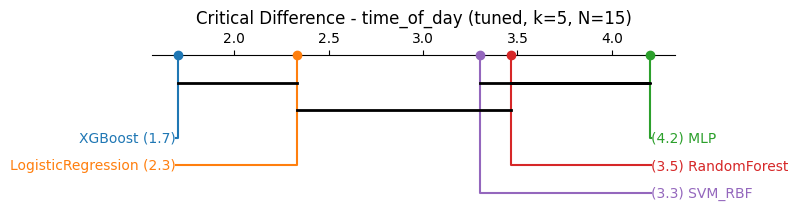

Saved: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml\results\v1.0-trainval\figures\cd_diagram_time_of_day.png

=== weather ===
Blocks(N)=15  Models(k)=5
Friedman chi2=28.4267  p=1.022e-05   (should match Table 6.2)
Average ranks (1 = best):
model
RandomForest          1.667
XGBoost               2.333
SVM_RBF               2.800
LogisticRegression    3.933
MLP                   4.267
Critical difference (CD), alpha=0.05: 1.575
Nemenyi pairwise p-values:
model               LogisticRegression     MLP  RandomForest  SVM_RBF  XGBoost
model                                                                         
LogisticRegression              1.0000  0.9784        0.0008   0.2843   0.0443
MLP                             0.9784  1.0000        0.0001   0.0819   0.0073
RandomForest                    0.0008  0.0001        1.0000   0.2843   0.7771
SVM_RBF                         0.2843  0.0819        0.2843   1.0000   0.9282
XGBoost                         0.0443  0.0073   

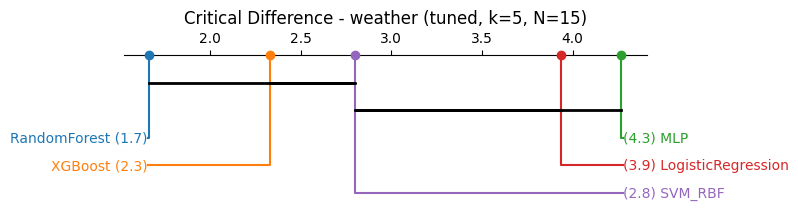

Saved: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml\results\v1.0-trainval\figures\cd_diagram_weather.png

=== vehicle_density ===
Blocks(N)=15  Models(k)=5
Friedman chi2=31.6267  p=2.28e-06   (should match Table 6.2)
Average ranks (1 = best):
model
SVM_RBF               1.667
XGBoost               2.333
MLP                   3.067
LogisticRegression    3.200
RandomForest          4.733
Critical difference (CD), alpha=0.05: 1.575
Nemenyi pairwise p-values:
model               LogisticRegression     MLP  RandomForest  SVM_RBF  XGBoost
model                                                                         
LogisticRegression              1.0000  0.9994        0.0607   0.0607   0.5617
MLP                             0.9994  1.0000        0.0318   0.1087   0.7096
RandomForest                    0.0607  0.0318        1.0000   0.0000   0.0003
SVM_RBF                         0.0607  0.1087        0.0000   1.0000   0.7771
XGBoost                         0.5617  0.7096

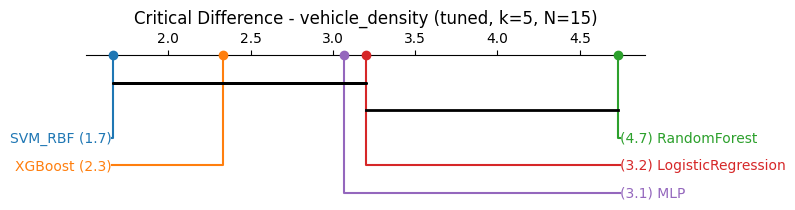

Saved: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml\results\v1.0-trainval\figures\cd_diagram_vehicle_density.png

=== vru_present ===
Blocks(N)=15  Models(k)=5
Friedman chi2=11.7867  p=0.01901   (should match Table 6.2)
Average ranks (1 = best):
model
SVM_RBF               1.933
XGBoost               2.867
MLP                   3.133
RandomForest          3.200
LogisticRegression    3.867
Critical difference (CD), alpha=0.05: 1.575
Nemenyi pairwise p-values:
model               LogisticRegression     MLP  RandomForest  SVM_RBF  XGBoost
model                                                                         
LogisticRegression              1.0000  0.7096        0.7771   0.0073   0.4141
MLP                             0.7096  1.0000        1.0000   0.2294   0.9907
RandomForest                    0.7771  1.0000        1.0000   0.1819   0.9784
SVM_RBF                         0.0073  0.2294        0.1819   1.0000   0.4866
XGBoost                         0.4141  0.9

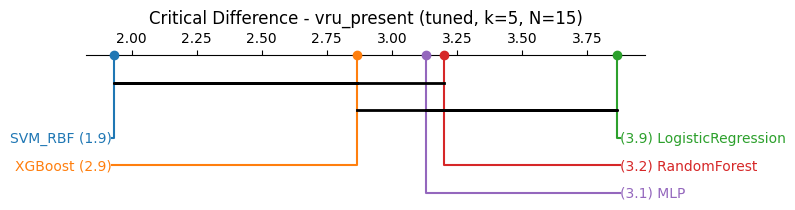

Saved: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml\results\v1.0-trainval\figures\cd_diagram_vru_present.png


In [7]:
# ---- Per-attribute: Friedman re-check + Nemenyi + ranks + CD diagram ----
tag = " (DEMO)" if DEMO else ""
summary_rows = []

for attr in ATTRIBUTES:
    sub = df[df[COL_ATTRIBUTE] == attr]
    mat = blocks_matrix(sub)
    if mat.shape[0] < 2 or mat.shape[1] < 3:
        print(f"[{attr}] skipped (blocks={mat.shape[0]}, models={mat.shape[1]})")
        continue

    k, N = mat.shape[1], mat.shape[0]
    chi2, p = friedmanchisquare(*[mat[c].values for c in mat.columns])

    nemenyi = sp.posthoc_nemenyi_friedman(mat.values)
    nemenyi.index = mat.columns
    nemenyi.columns = mat.columns

    ranks = mat.rank(axis=1, ascending=False).mean().sort_values()  # 1 = best
    cd = Q_ALPHA_05.get(k, np.nan) * np.sqrt(k * (k + 1) / (6.0 * N))

    print(f"\n=== {attr}{tag} ===")
    print(f"Blocks(N)={N}  Models(k)={k}")
    print(f"Friedman chi2={chi2:.4f}  p={p:.4g}   (should match Table 6.2)")
    print("Average ranks (1 = best):")
    print(ranks.round(3).to_string())
    print(f"Critical difference (CD), alpha={ALPHA}: {cd:.3f}")
    print("Nemenyi pairwise p-values:")
    print(nemenyi.round(4).to_string())

    cols = list(nemenyi.columns)
    sig = [f"{cols[i]} vs {cols[j]} (p={nemenyi.iloc[i, j]:.4f})"
           for i in range(len(cols)) for j in range(i + 1, len(cols))
           if nemenyi.iloc[i, j] < ALPHA]
    print("Significant pairs (p < %.2f): %s" % (ALPHA, "; ".join(sig) if sig else "none"))

    plt.figure(figsize=(8, 2.2))
    sp.critical_difference_diagram(ranks, nemenyi)
    plt.title(f"Critical Difference - {attr}{tag} (tuned, k={k}, N={N})")
    plt.tight_layout()
    out_png = os.path.join(OUT_DIR, f"cd_diagram_{attr}.png")
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_png}")

    summary_rows.append({
        "attribute": attr, "N_blocks": N, "k_models": k,
        "friedman_chi2": round(chi2, 4), "friedman_p": p,
        "CD_alpha05": round(cd, 3),
        "best_model": ranks.index[0], "best_rank": round(ranks.iloc[0], 3),
        "n_sig_pairs": len(sig),
    })

In [8]:
# ---- Compact summary (paste-ready) ----
if summary_rows:
    summary = pd.DataFrame(summary_rows)
    if not DEMO:
        out_csv = os.path.join(OUT_DIR, "nemenyi_summary.csv")
        summary.to_csv(out_csv, index=False)
        print("Saved:", out_csv)
    else:
        print("DEMO MODE - summary not saved.")
    display(summary)

Saved: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml\results\v1.0-trainval\figures\nemenyi_summary.csv


,attribute,N_blocks,k_models,friedman_chi2,friedman_p,CD_alpha05,best_model,best_rank,n_sig_pairs
0,time_of_day,15,5,25.6912,0.000037,1.575,XGBoost,1.700,4
1,weather,15,5,28.4267,0.000010,1.575,RandomForest,1.667,4
2,vehicle_density,15,5,31.6267,0.000002,1.575,SVM_RBF,1.667,3
3,vru_present,15,5,11.7867,0.019010,1.575,SVM_RBF,1.933,1


## Writing it into Section 6.4

Once the Friedman values match Table 6.2, report Nemenyi as supplementary post-hoc evidence:

- Per attribute, state which model pairs are **significantly different** (`p < 0.05`)
  and which are not. The pairs your chosen model is *not* significantly better than
  matter as much as the ones it beats.
- Note whether the best model's average-rank gap exceeds the **critical difference (CD)**;
  if not, the top models are statistically tied.
- Add a CD diagram figure and keep the **non-independent blocks** caveat.


In [9]:
import os, ast
from pathlib import Path
from collections import Counter
import pandas as pd

def _repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        if (base / ".git").exists(): return base
        if (base / "notebooks").is_dir() and (base / "results").is_dir(): return base
    return start

REPO_ROOT     = _repo_root()
RESULTS_CSV   = str(REPO_ROOT / "results" / "v1.0-trainval" / "metrics" / "all_metrics.csv")
OUT_DIR       = str(REPO_ROOT / "results" / "v1.0-trainval" / "metrics")
COL_MODEL, COL_ATTRIBUTE, COL_CONFIG = "model", "attribute", "version"
TUNED_VALUE   = "tuned"

df = pd.read_csv(RESULTS_CSV)
tuned = df[df[COL_CONFIG] == TUNED_VALUE].copy()

In [10]:
# ---- Modal selected hyperparameters per model/attribute ----
import ast
from collections import Counter

tuned = df[df[COL_CONFIG] == TUNED_VALUE].copy()

def parse_params(x):
    if pd.isna(x): return {}
    if isinstance(x, dict): return x
    try:
        return ast.literal_eval(str(x))
    except (ValueError, SyntaxError):
        return {}

def clean_key(k):
    for p in ("clf__", "classifier__", "model__", "estimator__"):
        if k.startswith(p): return k[len(p):]
    return k

tuned["params"] = tuned["best_params"].apply(parse_params)

out = []
for (model, attr), grp in tuned.groupby([COL_MODEL, COL_ATTRIBUTE]):
    n = len(grp)
    keys = sorted({k for d in grp["params"] for k in d})
    parts = []
    for k in keys:
        vals = [d[k] for d in grp["params"] if k in d]
        val, freq = Counter(str(v) for v in vals).most_common(1)[0]
        parts.append(f"{clean_key(k)}={val} ({freq}/{n})")
    out.append({"model": model, "attribute": attr,
                "selected_hyperparameters": "; ".join(parts) if parts else "(none)"})

modal = pd.DataFrame(out).sort_values(["model", "attribute"]).reset_index(drop=True)
display(modal)
modal.to_csv(os.path.join(OUT_DIR, "modal_hyperparameters.csv"), index=False)
print("Saved:", os.path.join(OUT_DIR, "modal_hyperparameters.csv"))

,model,attribute,selected_hyperparameters
0,LogisticRegression,time_of_day,C=1.0 (7/15)
1,LogisticRegression,vehicle_density,C=0.01 (15/15)
2,LogisticRegression,vru_present,C=0.01 (15/15)
3,LogisticRegression,weather,C=0.1 (9/15)
4,MLP,time_of_day,"alpha=0.0001 (15/15); hidden_layer_sizes=(64,)..."
5,MLP,vehicle_density,"alpha=0.001 (12/15); hidden_layer_sizes=(256,)..."
6,MLP,vru_present,"alpha=0.001 (10/15); hidden_layer_sizes=(256,)..."
7,MLP,weather,"alpha=0.0001 (13/15); hidden_layer_sizes=(128,..."
8,RandomForest,time_of_day,max_depth=None (13/15); min_samples_split=5 (7...
9,RandomForest,vehicle_density,max_depth=30 (10/15); min_samples_split=5 (7/15)


Saved: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml\results\v1.0-trainval\metrics\modal_hyperparameters.csv
